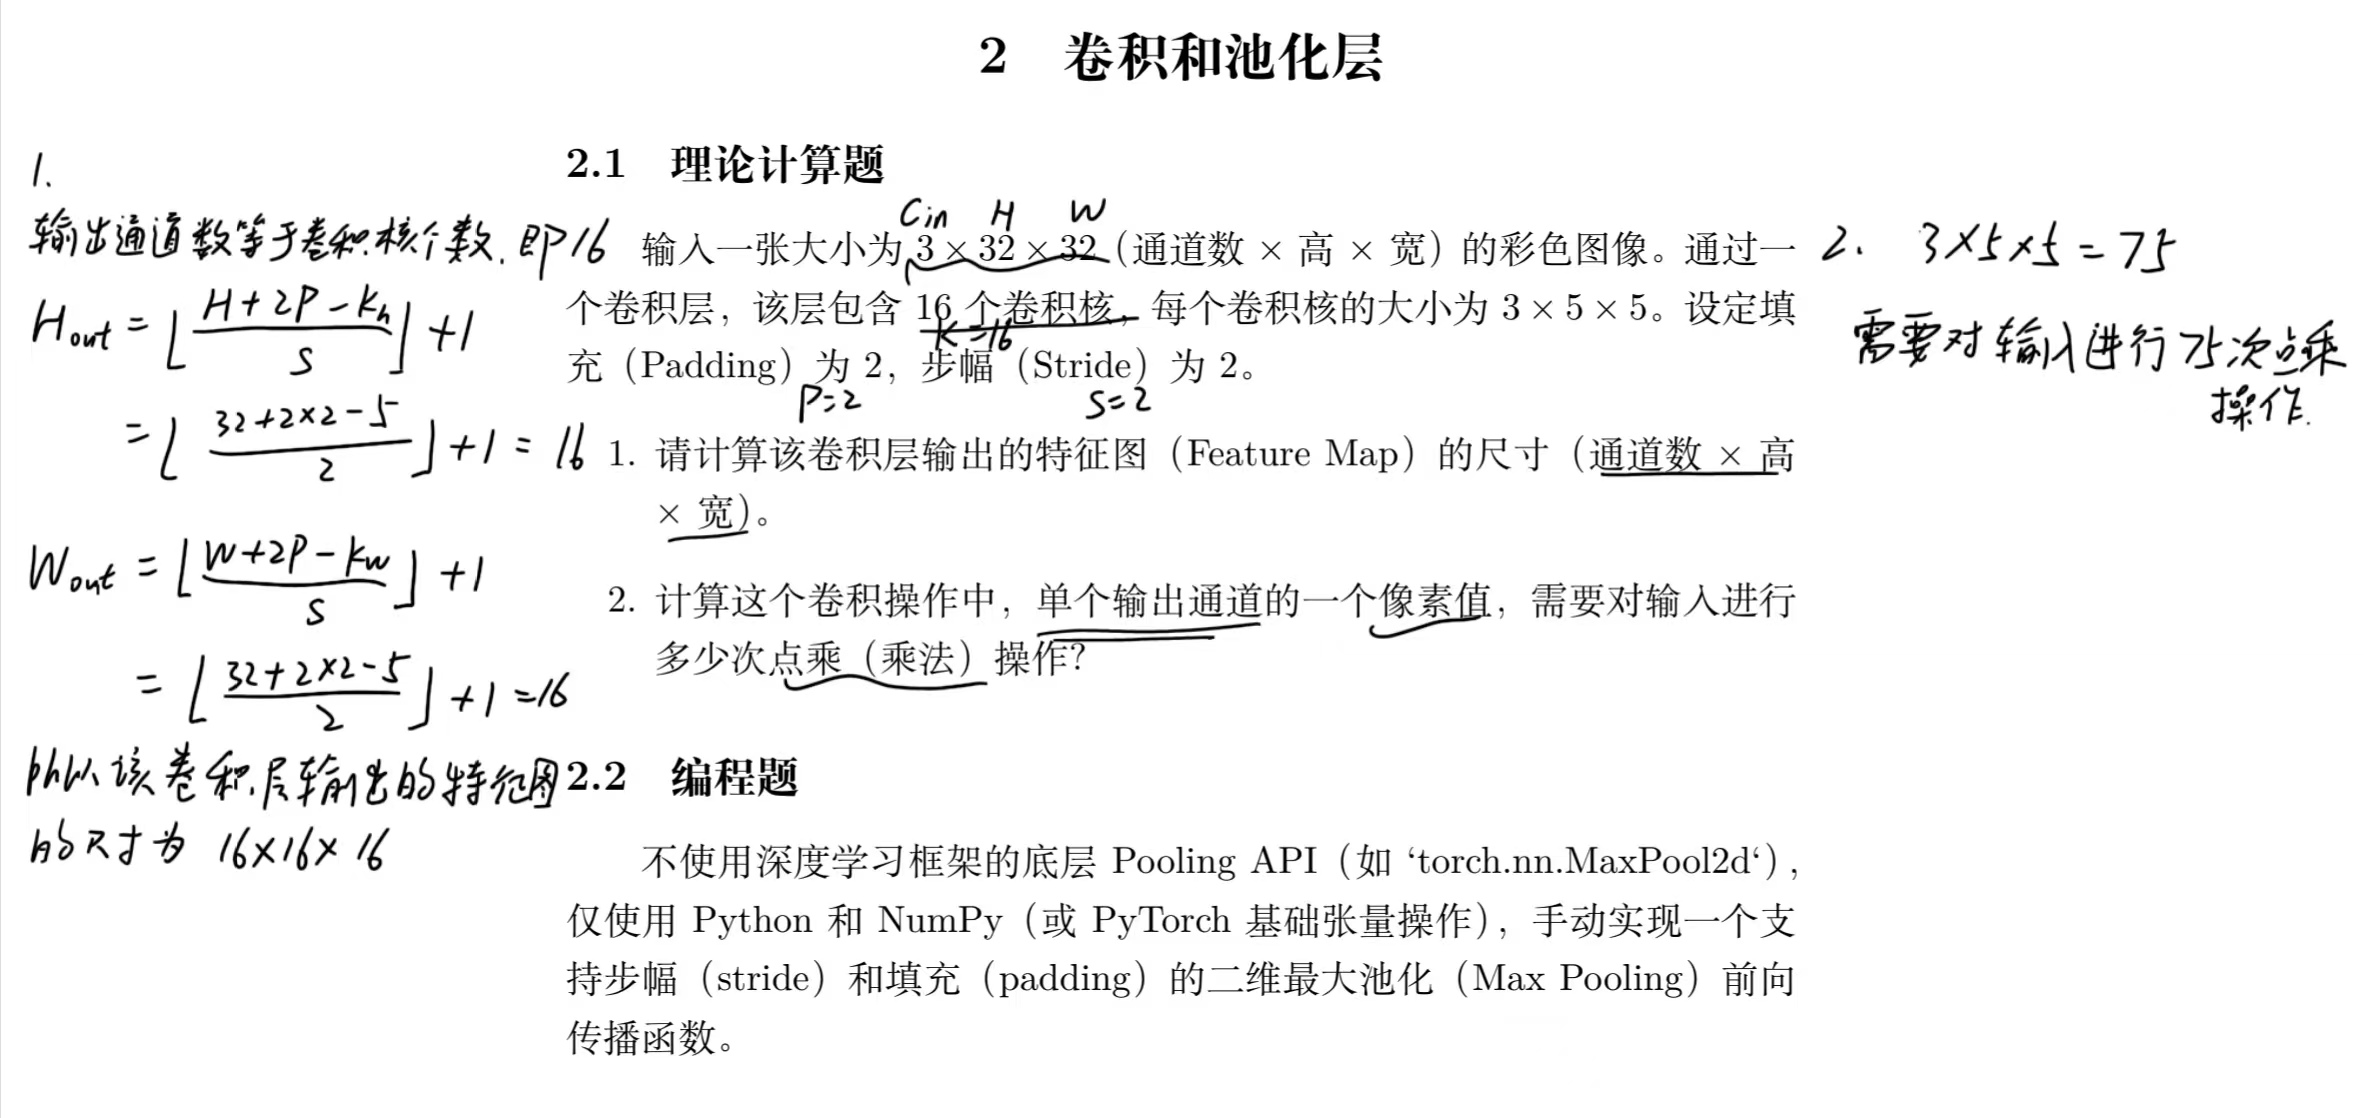

In [ ]:
import torch
import torch.nn.functional as F

def max_pool2d_manual(x, kernel_size, stride, padding):
    """
    手动实现二维最大池化前向传播
    x: 输入张量，形状 (N, C, H, W)
    kernel_size: 池化核大小 (int 或 tuple)
    stride: 步幅 (int 或 tuple)
    padding: 填充 (int 或 tuple)
    """
    # 统一为元组
    if isinstance(kernel_size, int):
        kernel_size = (kernel_size, kernel_size)
    if isinstance(stride, int):
        stride = (stride, stride)
    if isinstance(padding, int):
        padding = (padding, padding)
    
    N, C, H, W = x.shape
    kh, kw = kernel_size
    sh, sw = stride
    ph, pw = padding
    
    # 填充
    x_pad = F.pad(x, (pw, pw, ph, ph), mode='constant', value=float('-inf'))
    H_pad, W_pad = H + 2*ph, W + 2*pw
    
    # 计算输出尺寸
    H_out = (H_pad - kh) // sh + 1
    W_out = (W_pad - kw) // sw + 1
    
    # 使用 unfold 提取滑动窗口
    # unfold 输出形状 (N, C, H_out*W_out, kh*kw)
    windows = x_pad.unfold(2, kh, sh).unfold(3, kw, sw)
    windows = windows.contiguous().view(N, C, H_out, W_out, -1)
    
    # 取最大值
    out, _ = windows.max(dim=-1)
    return out

# 测试
if __name__ == "__main__":
    x = torch.randn(2, 3, 32, 32)
    out = max_pool2d_manual(x, kernel_size=2, stride=2, padding=0)
    print("输入形状:", x.shape)
    print("手动池化输出形状:", out.shape)
    # 对比 torch 原生池化
    out_torch = F.max_pool2d(x, kernel_size=2, stride=2, padding=0)
    print("torch池化输出形状:", out_torch.shape)
    print("结果是否一致:", torch.allclose(out, out_torch))

输入形状: torch.Size([2, 3, 32, 32])
手动池化输出形状: torch.Size([2, 3, 16, 16])
torch池化输出形状: torch.Size([2, 3, 16, 16])
结果是否一致: True


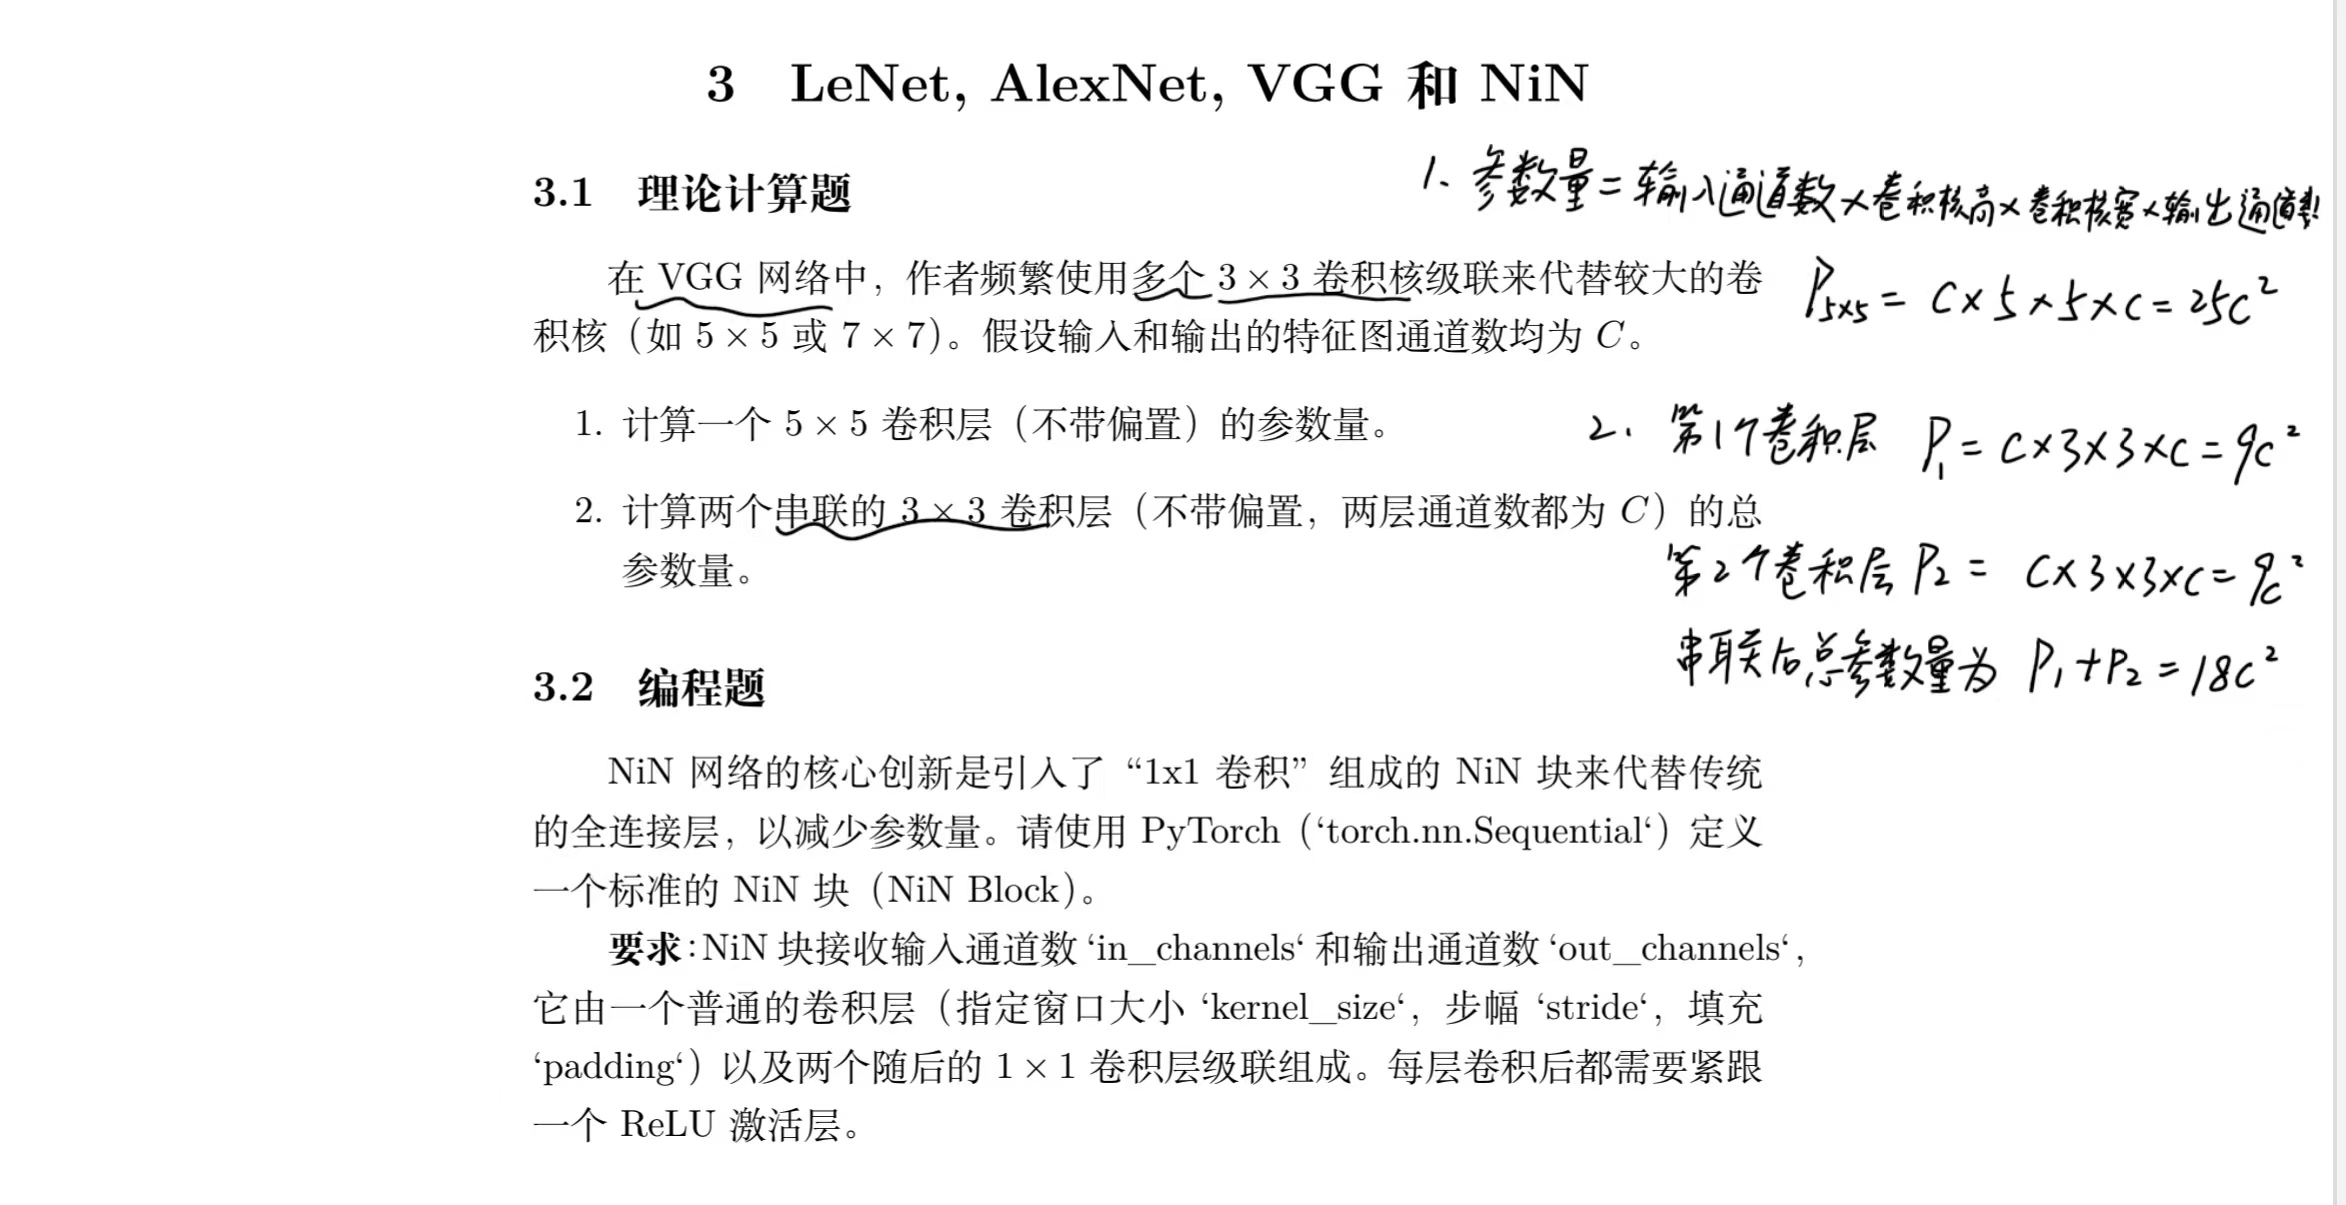

In [ ]:
import torch
import torch.nn as nn

def make_nin_block(in_channels, out_channels, kernel_size, stride, padding):
    """
    创建 NiN 块: 一个普通卷积 + 两个 1x1 卷积，每个后接 ReLU
    """
    return nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding),
        nn.ReLU(),
        nn.Conv2d(out_channels, out_channels, kernel_size=1),
        nn.ReLU(),
        nn.Conv2d(out_channels, out_channels, kernel_size=1),
        nn.ReLU()
    )

# 测试
if __name__ == "__main__":
    block = make_nin_block(3, 16, kernel_size=3, stride=1, padding=1)
    x = torch.randn(1, 3, 32, 32)
    out = block(x)
    print("NiN块结构:\n", block)
    print("输入形状:", x.shape)
    print("输出形状:", out.shape)

NiN块结构:
 Sequential(
  (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1))
  (3): ReLU()
  (4): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1))
  (5): ReLU()
)
输入形状: torch.Size([1, 3, 32, 32])
输出形状: torch.Size([1, 16, 32, 32])


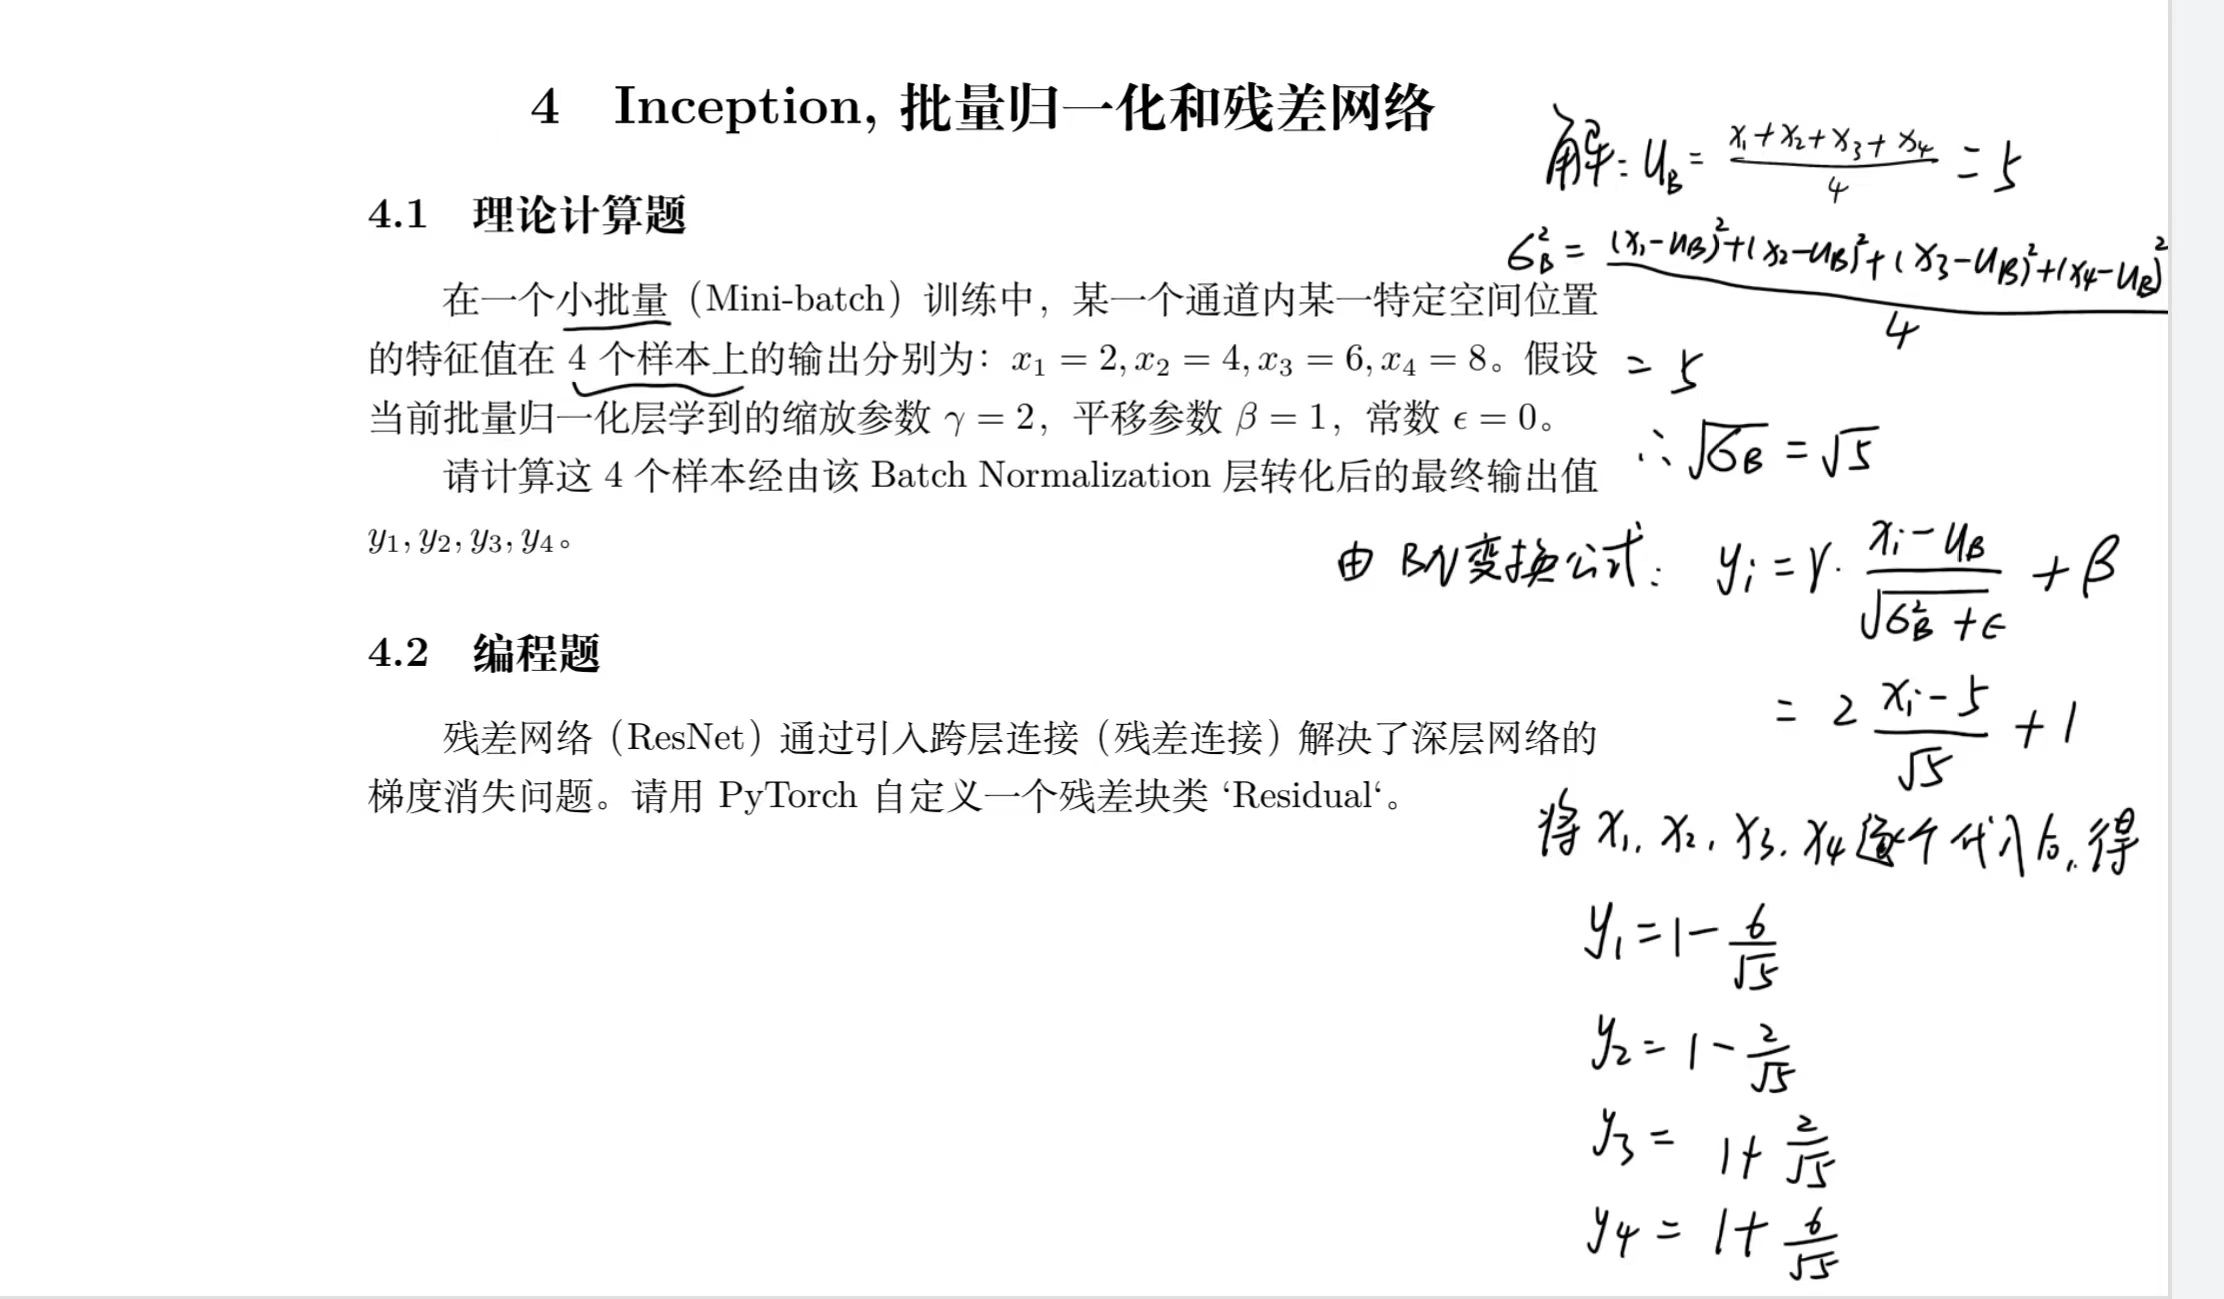

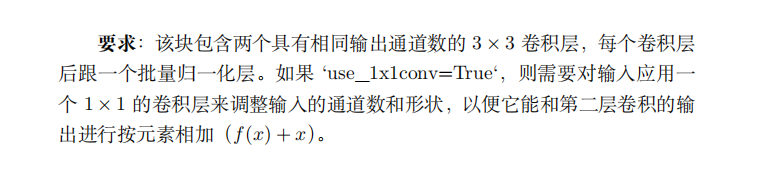

In [ ]:
import torch
import torch.nn as nn

class Residual(nn.Module):
    def __init__(self, in_channels, out_channels, use_1x1conv=False, stride=1):
        super().__init__()
        # 第一个卷积块: 3x3, BN, ReLU
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        # 第二个卷积块: 3x3, BN
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)
        
        # 短路连接
        if use_1x1conv:
            self.shortcut = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride)
        else:
            self.shortcut = nn.Identity() if in_channels == out_channels and stride == 1 else None
    
    def forward(self, x):
        identity = x
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        
        if self.shortcut is not None:
            identity = self.shortcut(x)
        # 如果 shortcut 为 None，则要求 in_channels == out_channels 且 stride=1，直接相加
        out += identity
        out = self.relu(out)
        return out

# 测试
if __name__ == "__main__":
    # 测试两种情况
    block1 = Residual(3, 64, use_1x1conv=True, stride=2)
    block2 = Residual(64, 64, use_1x1conv=False)
    x = torch.randn(1, 3, 32, 32)
    out1 = block1(x)
    out2 = block2(out1)
    print("残差块1 (降采样):", block1)
    print("输入3x32x32 -> 输出", out1.shape)
    print("残差块2 (恒等):", block2)
    print("输出", out2.shape)

残差块1 (降采样): Residual(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (shortcut): Conv2d(3, 64, kernel_size=(1, 1), stride=(2, 2))
)
输入3x32x32 -> 输出 torch.Size([1, 64, 16, 16])
残差块2 (恒等): Residual(
  (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (shortcut): Identity()
)
输出 torch.Size([1, 64, 16, 16])


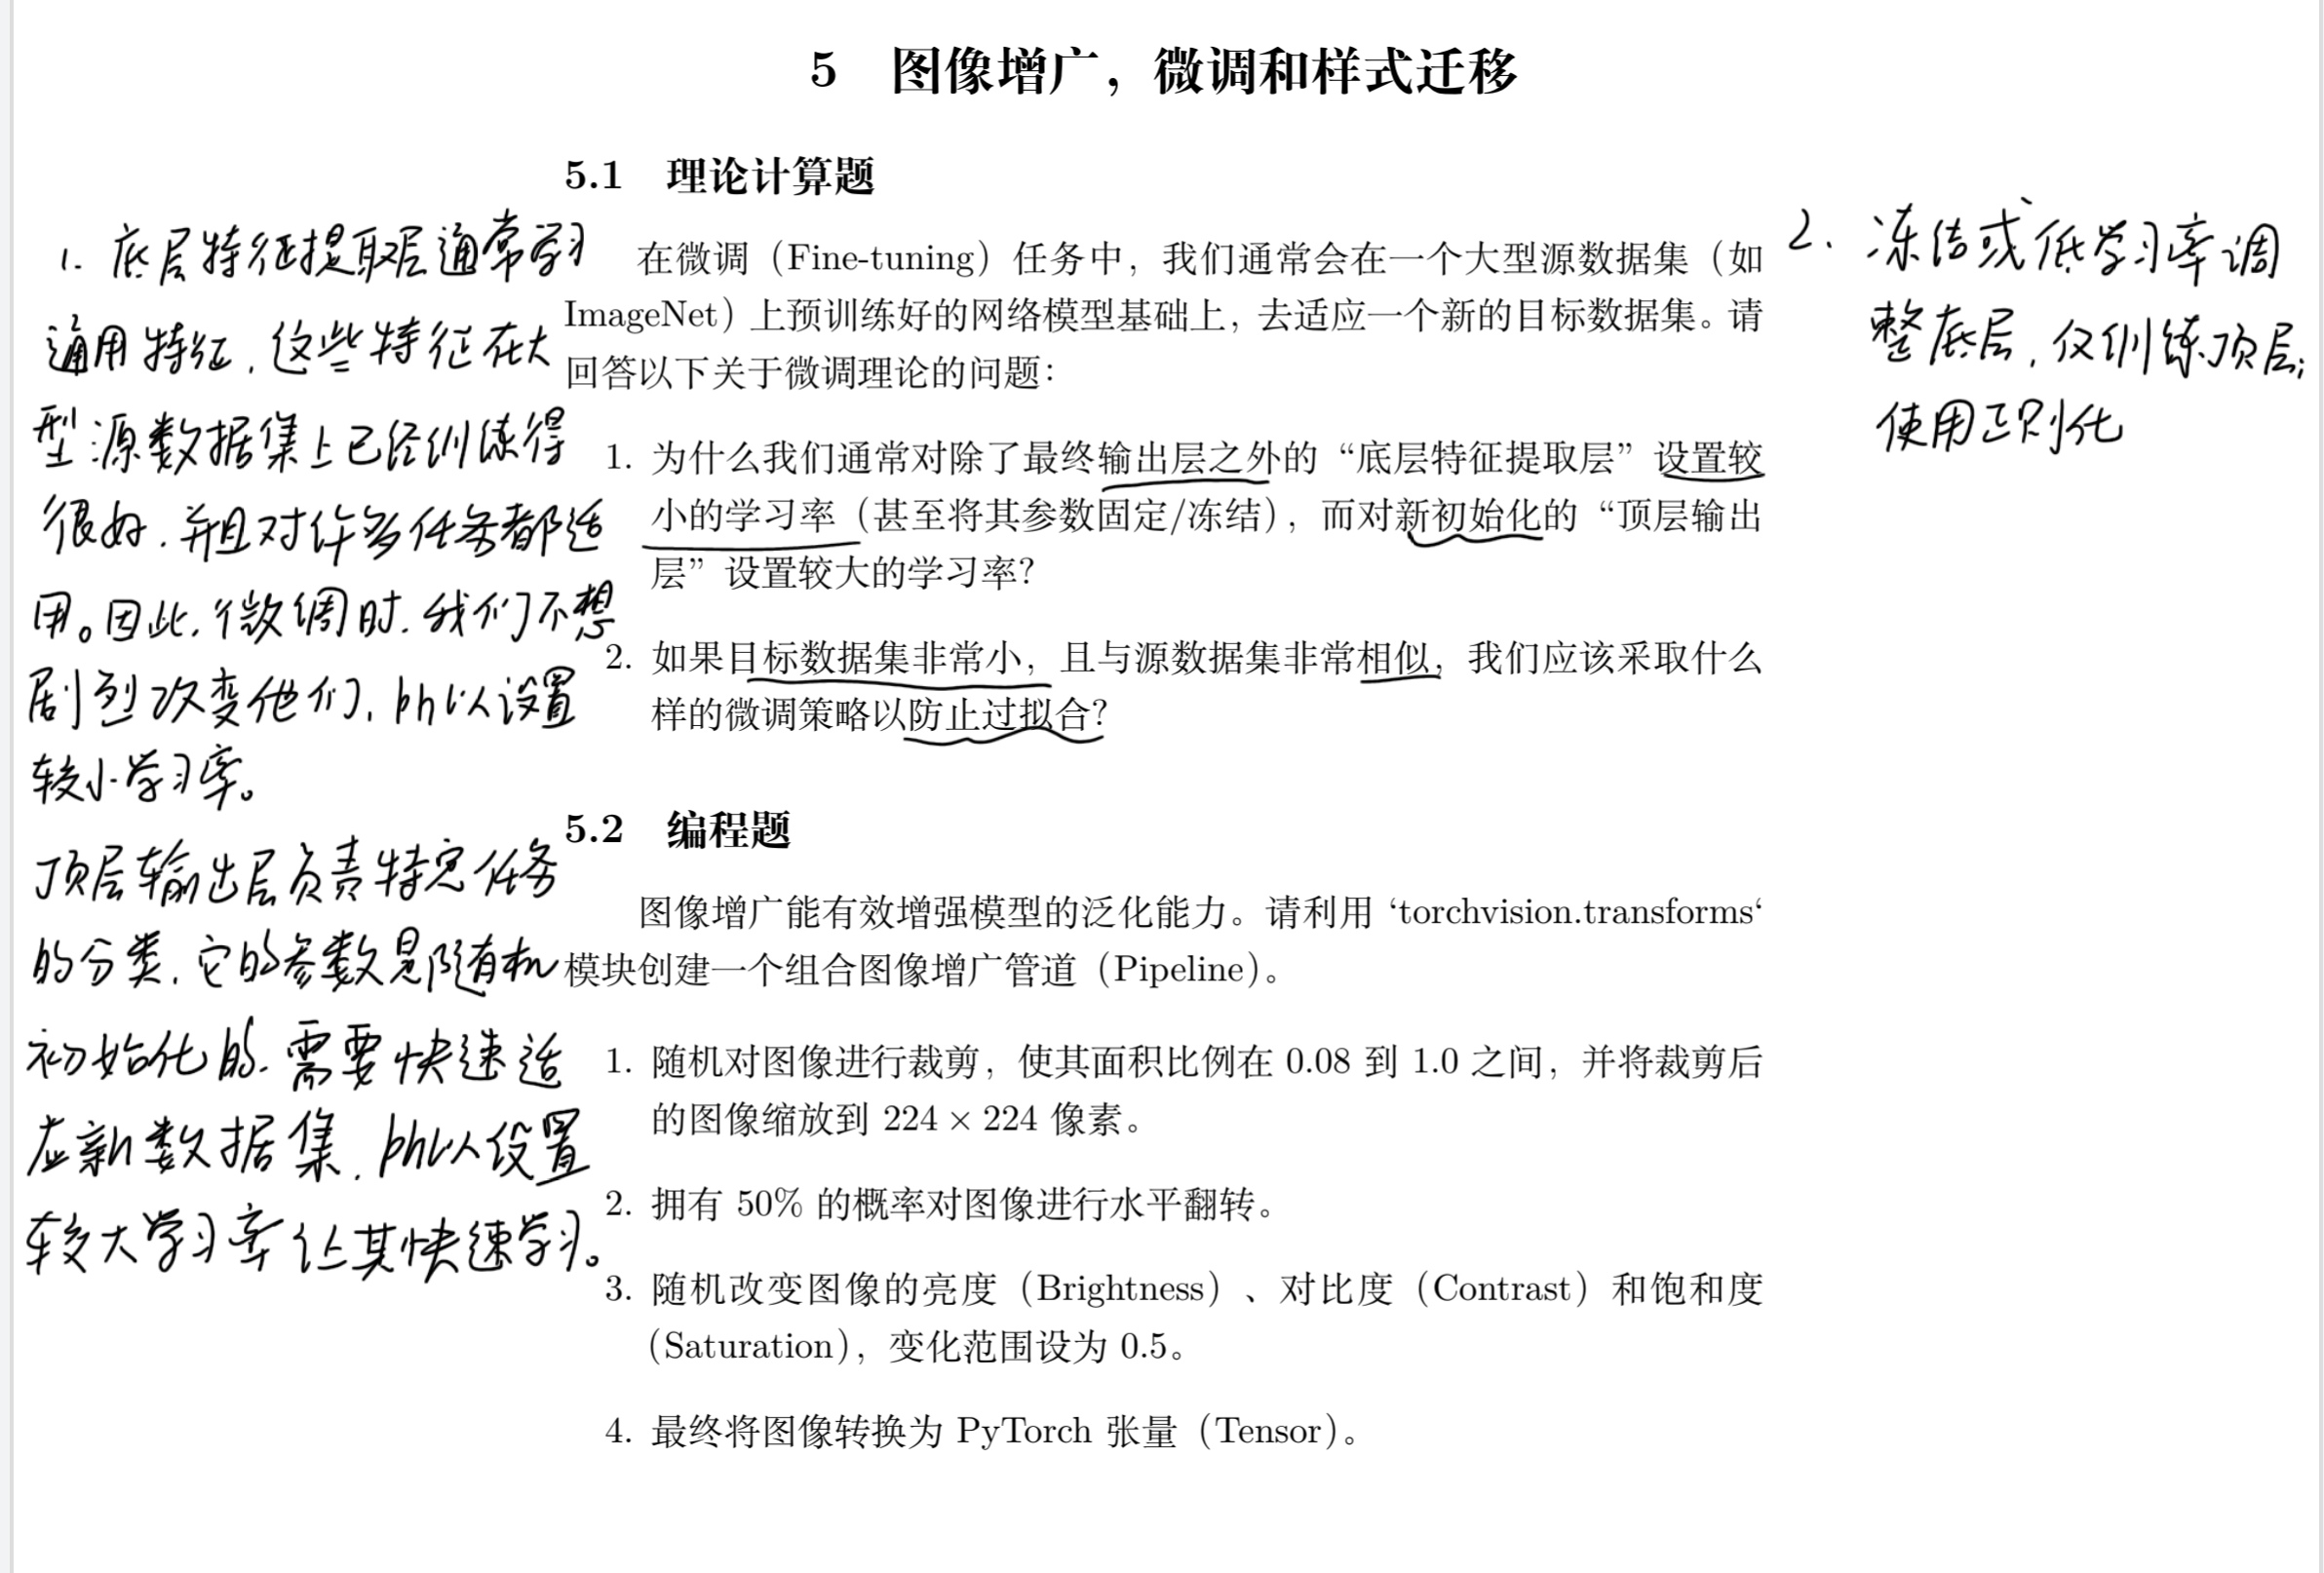

In [ ]:
import torchvision.transforms as T
from PIL import Image
import torch

# 创建增广管道
augmentation_pipeline = T.Compose([
    T.RandomResizedCrop(224, scale=(0.08, 1.0)),
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5),
    T.ToTensor()
])

# 打印管道结构
print("图像增广管道:\n", augmentation_pipeline)

# 可选: 演示对一个随机图像进行变换
if __name__ == "__main__":
    # 创建一个随机 RGB 图像 (H, W) 或直接用张量模拟，但 ToTensor 要求 PIL 或 numpy
    dummy_img = Image.new('RGB', (300, 300), color='red')
    tensor_img = augmentation_pipeline(dummy_img)
    print("演示: 随机图像变换后的张量形状:", tensor_img.shape)

图像增广管道:
 Compose(
    RandomResizedCrop(size=(224, 224), scale=(0.08, 1.0), ratio=(0.75, 1.3333), interpolation=bilinear, antialias=True)
    RandomHorizontalFlip(p=0.5)
    ColorJitter(brightness=(0.5, 1.5), contrast=(0.5, 1.5), saturation=(0.5, 1.5), hue=None)
    ToTensor()
)
演示: 随机图像变换后的张量形状: torch.Size([3, 224, 224])


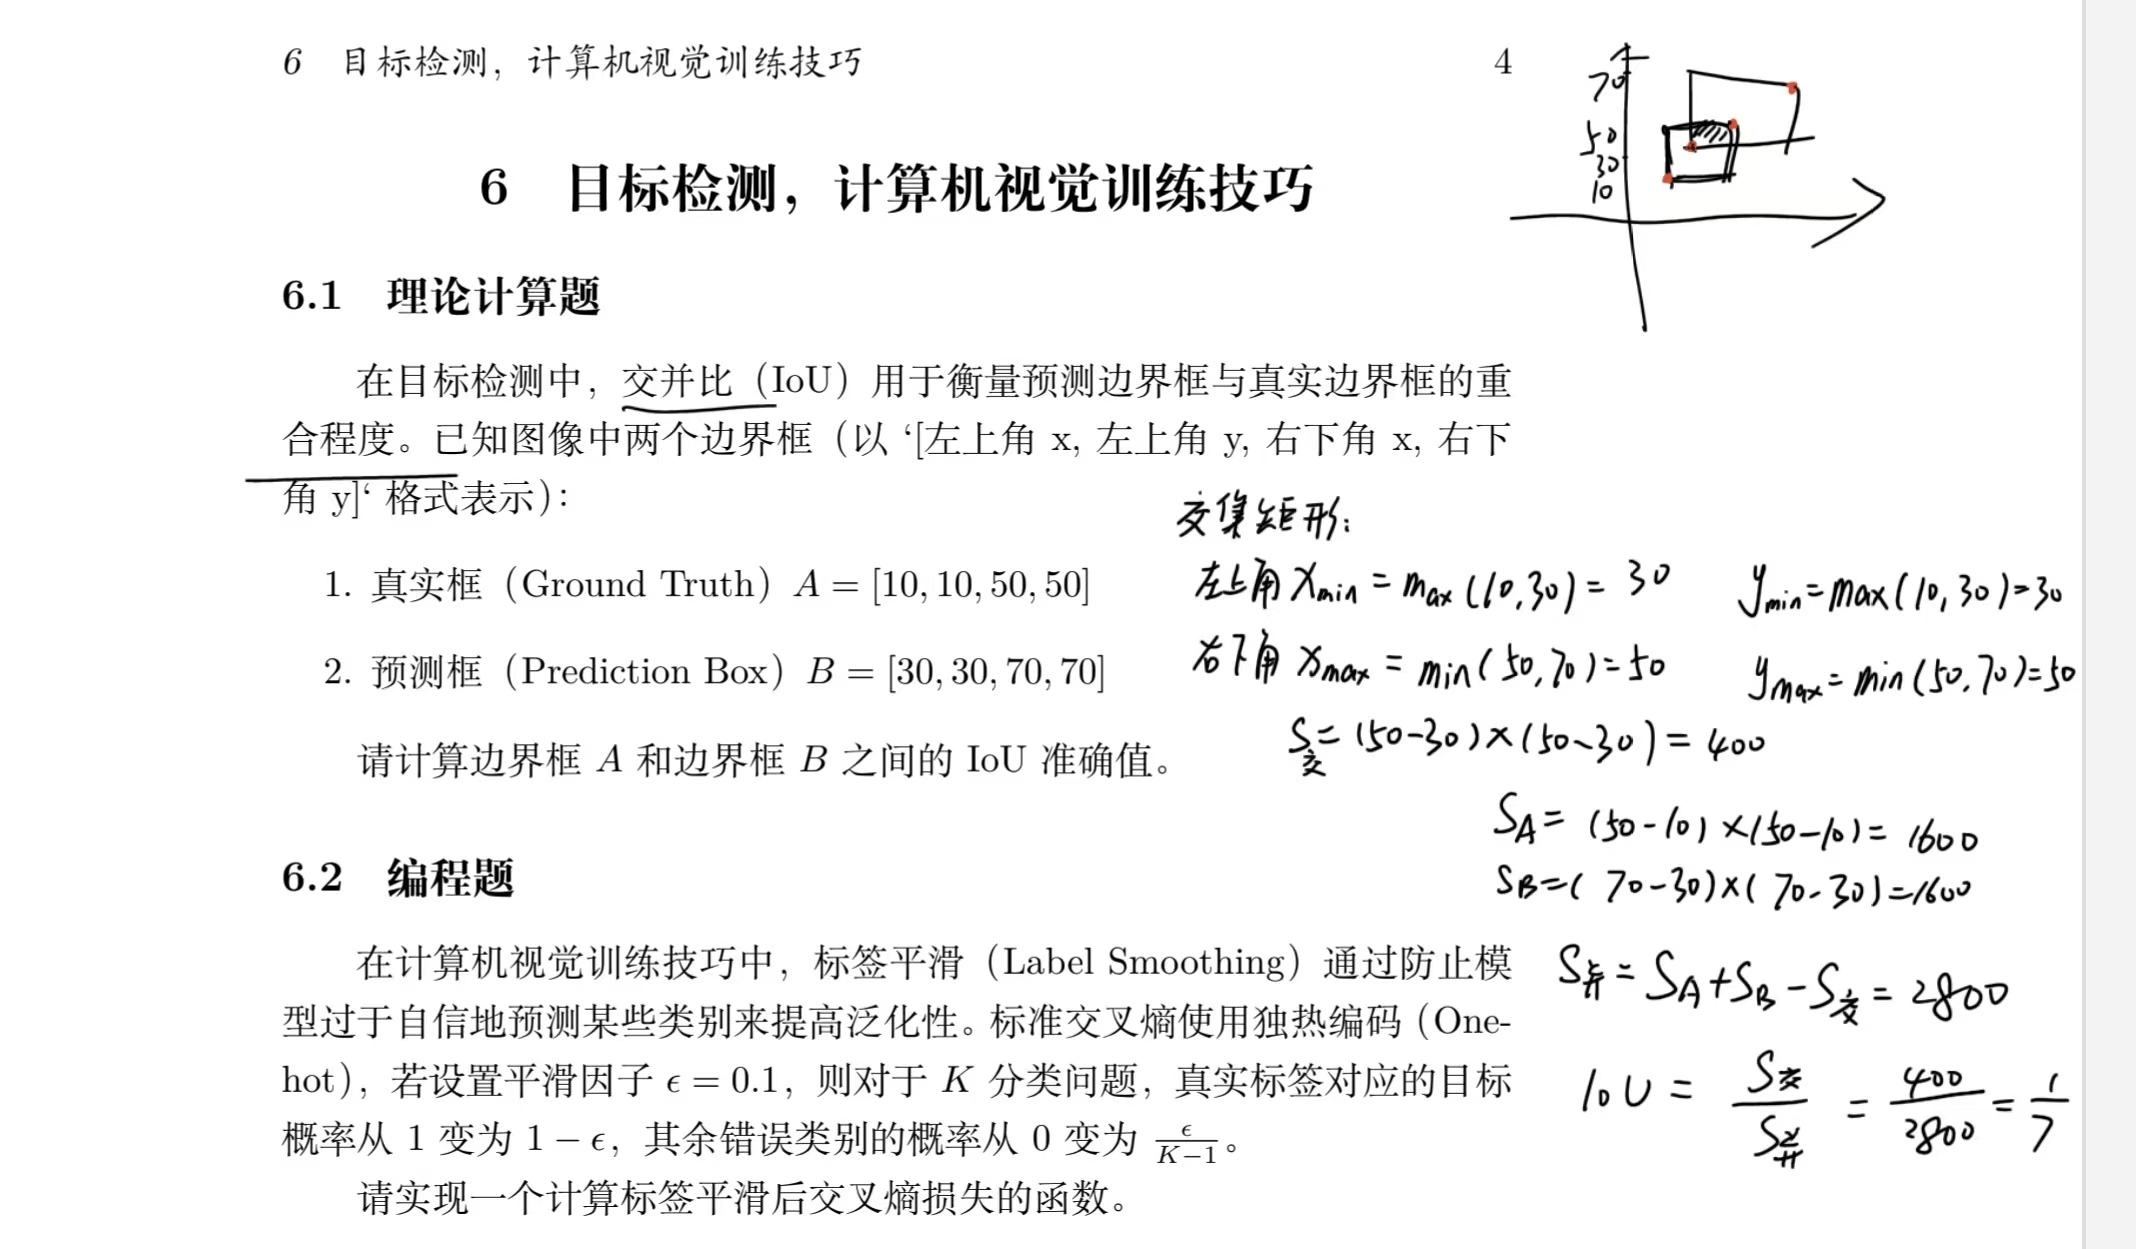

In [ ]:
import torch
import torch.nn.functional as F

def label_smoothing_cross_entropy(logits, labels, epsilon=0.1):
    """
    计算标签平滑后的交叉熵损失
    logits: 模型输出，形状 (batch_size, num_classes)
    labels: 真实类别索引，形状 (batch_size,)
    epsilon: 平滑因子
    """
    num_classes = logits.shape[-1]
    # 计算 softmax 概率
    log_probs = F.log_softmax(logits, dim=-1)
    # 构造平滑后的目标分布
    smooth_target = torch.full_like(log_probs, epsilon / (num_classes - 1))
    smooth_target.scatter_(1, labels.unsqueeze(1), 1.0 - epsilon)
    # 计算交叉熵: -sum(target * log_prob)
    loss = - (smooth_target * log_probs).sum(dim=-1).mean()
    return loss

# 测试
if __name__ == "__main__":
    # 假设 5 分类，batch_size=3
    logits = torch.randn(3, 5)
    labels = torch.tensor([0, 2, 4])
    loss = label_smoothing_cross_entropy(logits, labels, epsilon=0.1)
    print("标签平滑交叉熵损失:", loss.item())
    
    # 对比标准交叉熵
    ce_loss = F.cross_entropy(logits, labels)
    print("标准交叉熵损失:", ce_loss.item())

标签平滑交叉熵损失: 1.9977833032608032
标准交叉熵损失: 1.9850956201553345
